# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


In [204]:
notebook_dir

'/mnt/ceph/users/blyo1/projects/hdiva'

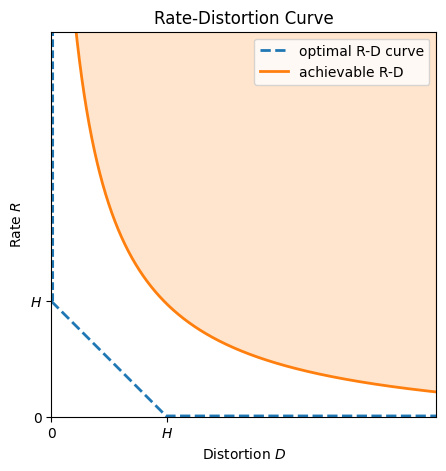

In [162]:
# first get the R-D curve

plots=(1, 1)
fig, ax = plt.subplots(*plots, figsize=(plots[-1]*5, 5))

H = 3
d = np.linspace(0, 10, 1000)
r_opt = H - d
r_opt[r_opt < 0] = 0.02

ax.plot(d, r_opt, label='optimal R-D curve', color='tab:blue', linewidth=2, zorder=1, linestyle='dashed')
ax.vlines(0.05, H, 10, colors='tab:blue', linestyles='dashed')
ax.set_xlabel('Distortion $D$')
ax.set_ylabel('Rate $R$')
ax.set_title('Rate-Distortion Curve')
ax.set(xticks=(0, 3), yticks=(0, 3), xticklabels=['0', '$H$'], yticklabels=['0', '$H$'])

offset = 0.5
r_2 = 12/(d+offset) - offset
ax.plot(d, r_2, label='achievable R-D', color='tab:orange', linewidth=2, zorder=1)

# shade values above this line
ax.fill_between(d, r_2, 10, color='tab:orange', alpha=0.2, zorder=0)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.legend()
plt.show()

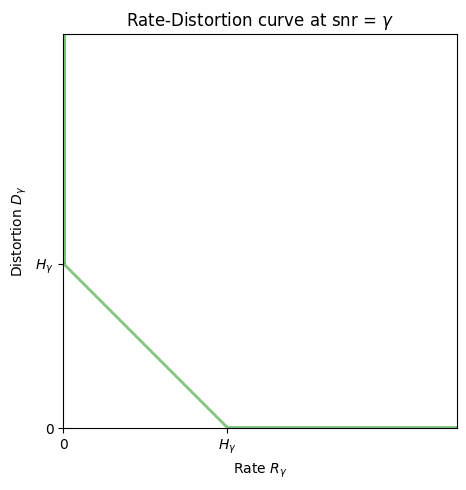

In [226]:
# now get the R-D curve for multiple gammas
plots=(1, 1)
fig, ax = plt.subplots(*plots, figsize=(plots[-1]*5, 5))
color = 'tab:green'

offset0 = 0
offset1 = 5

d = np.linspace(0, 12, 1000)

r_opt1 = offset1 - d + .02
r_opt1[r_opt1 < 0] = 0.02


ax.plot(d, r_opt1, color=color, linewidth=2, zorder=1, alpha=.6)
ax.vlines(0.05, offset1, 12, colors=color, alpha=.6)

ax.set_ylabel('Distortion $D_{\\gamma}$')
ax.set_xlabel('Rate $R_{\\gamma}$')
ax.set_title('Rate-Distortion curve at snr = $\gamma$')


# shade values above this line
ax.set(xticks=(0, offset1), yticks=(0, offset1))
ax.set(xticklabels=['0', '$H_{\\gamma}$'])
ax.set(yticklabels=['0', '$H_{\\gamma}$'])

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
fig.tight_layout()
plt.savefig(f'{notebook_dir}/d_analysis/figures/RD_one_gamma.pdf', dpi=300)
plt.savefig(f'{notebook_dir}/d_analysis/figures/RD_one_gamma.png', dpi=300)
plt.show()

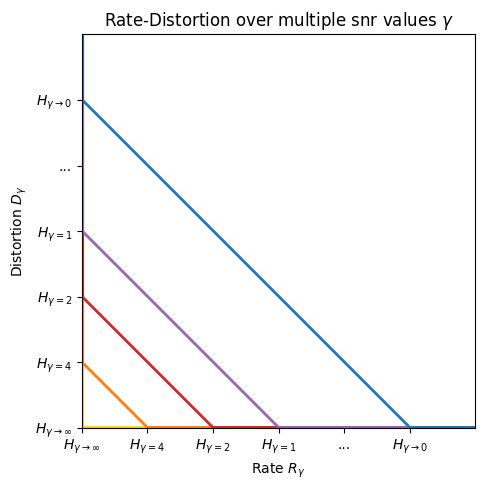

In [286]:
# now get the R-D curve for multiple gammas
plots=(1, 1)
fig, ax = plt.subplots(*plots, figsize=(plots[-1]*5, 5))

offset0 = 0
offset1 = 2
offset2 = 4
offset3 = 6
offset4 = 8
offset_inf = 10

d = np.linspace(0, 12, 1000)
r_opt0 = np.zeros_like(d) + .02

r_opt1 = offset1 - d + .02
r_opt1[r_opt1 < 0] = 0.02

r_opt2 = offset2 - d + .02
r_opt2[r_opt2 < 0] = 0.02

r_opt3 = offset3 - d + .02
r_opt3[r_opt3 < 0] = 0.02

r_opt_inf = offset_inf - d + 0.02
r_opt_inf[r_opt_inf < 0] = 0.02

ax.plot(d, r_opt0, color='gold', linewidth=2, alpha=1.0)
ax.vlines(0.05, offset0, 12, colors='gold', alpha=1.0)

ax.plot(d, r_opt1, color='tab:orange', linewidth=2, alpha=1.0)
ax.vlines(0.05, offset1, 12, colors='tab:orange', alpha=1.0)

ax.plot(d, r_opt2, color='tab:red',    linewidth=2, alpha=1.0)
ax.vlines(0.05, offset2, 12, colors='tab:red', alpha=1.0)

ax.plot(d, r_opt3, color='tab:purple', linewidth=2, alpha=1.0)
ax.vlines(0.05, offset3, 12, colors='tab:purple', alpha=1.0)

ax.plot(d, r_opt_inf, color='tab:blue', linewidth=2)
ax.vlines(0.05, offset_inf, 12, colors='tab:blue')

ax.set_ylabel('Distortion $D_{\\gamma}$')
ax.set_xlabel('Rate $R_{\\gamma}$')
ax.set_title('Rate-Distortion over multiple snr values $\gamma$')

# shade values above this line
ax.set(xticks=(offset0, offset1, offset2, offset3, offset4, offset_inf), yticks=(offset0, offset1, offset2, offset3, offset4, offset_inf))
ax.set(xticklabels=['$H_{\\gamma\\rightarrow\\infty}$', '$H_{\\gamma=4}$', '$H_{\\gamma=2}$', '$H_{\\gamma=1}$', '...', '$H_{\\gamma\\rightarrow 0}$'])
ax.set(yticklabels=['$H_{\\gamma\\rightarrow\\infty}$', '$H_{\\gamma=4}$', '$H_{\\gamma=2}$', '$H_{\\gamma=1}$', '...', '$H_{\\gamma\\rightarrow 0}$'])

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
fig.tight_layout()
plt.savefig(f'{notebook_dir}/d_analysis/figures/RD_multiple_gamma.pdf', dpi=300)
plt.savefig(f'{notebook_dir}/d_analysis/figures/RD_multiple_gamma.png', dpi=300)
plt.show()

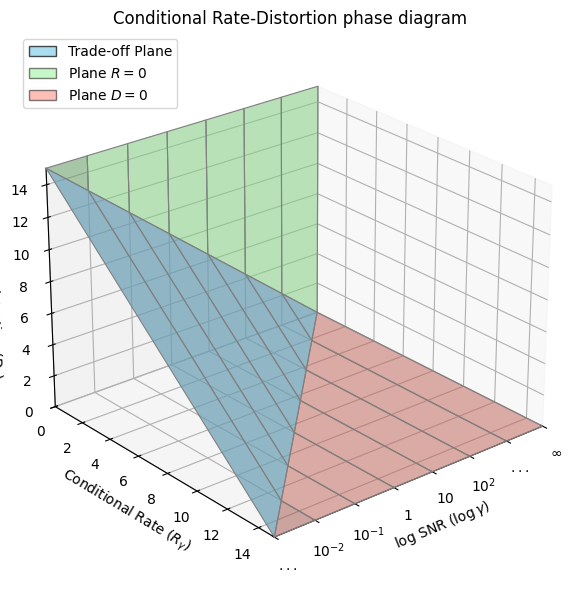

In [288]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Parameters
gamma_max = 10
c = 1.5
D_max = c * gamma_max
R_max = c * gamma_max

# We define exactly 11 distinct points for SNR to create clean grid lines.
gamma_vals = np.linspace(0, gamma_max, 8)

# By limiting the fractional parameters to JUST the endpoints (0 and 1), 
# we prevent Matplotlib from drawing the internal "fanning" cross-lines.
t_vals = np.array([0.0, 1.0])

# 1. Main trade-off plane
Gamma_main, T = np.meshgrid(gamma_vals, t_vals)
H_XZ = c * Gamma_main
R_main = T * H_XZ
D_main = (1 - T) * H_XZ

# 2. Plane R = 0
Gamma_R0, U_R0 = np.meshgrid(gamma_vals, t_vals)
R_R0 = np.zeros_like(Gamma_R0)
D_R0 = c * Gamma_R0 + U_R0 * (D_max - c * Gamma_R0)

# 3. Plane D = 0
Gamma_D0, U_D0 = np.meshgrid(gamma_vals, t_vals)
D_D0 = np.zeros_like(Gamma_D0)
R_D0 = c * Gamma_D0 + U_D0 * (R_max - c * Gamma_D0)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Using black edgecolors natively on the plot_surface to draw the clean grid
surf_main = ax.plot_surface(Gamma_main, R_main, D_main, color='skyblue', edgecolor='grey', linewidth=0.8, alpha=0.7)
surf_R0 = ax.plot_surface(Gamma_R0, R_R0, D_R0, color='lightgreen', edgecolor='grey', linewidth=0.8, alpha=0.5)
surf_D0 = ax.plot_surface(Gamma_D0, R_D0, D_D0, color='salmon', edgecolor='grey', linewidth=0.8, alpha=0.5)

ax.set_xlabel('log SNR ($\\log \\gamma$)')
ax.set_ylabel('Conditional Rate ($R_{\\gamma}$)')
ax.set_zlabel('Conditional Distortion ($D_{\\gamma}$)')
ax.set_title('Conditional Rate-Distortion phase diagram')

# Legends
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', alpha=0.7, label='Trade-off Plane'),
    Patch(facecolor='lightgreen', edgecolor='black', alpha=0.5, label='Plane $R=0$'),
    Patch(facecolor='salmon', edgecolor='black', alpha=0.5, label='Plane $D=0$')
]
ax.legend(handles=legend_elements, loc='upper left')

ax.set(xticks=gamma_vals)
ax.set(xticklabels=['$\\infty$', '$...$', '$10^2$', '$10$', '$1$', '$10^{-1}$', '$10^{-2}$', '$...$'])

# Adjust viewing angle
ax.view_init(elev=25, azim=50)

# Set axis limits
ax.set_xlim(0, gamma_max)
ax.set_ylim(0, R_max)
ax.set_zlim(0, D_max)

fig.canvas.draw()
plt.tight_layout()
plt.savefig(f'{notebook_dir}/d_analysis/figures/RDG_3d.pdf', dpi=300)
plt.savefig(f'{notebook_dir}/d_analysis/figures/RDG_3d.png', dpi=300)